In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import yfinance as yf
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

In [2]:

tickers = [
    "MSFT",
    "GOOGL",
    "NVDA",
    "AMZN",
    "AVGO",
    "JPM",
    "JNJ",
    "KO",
    "V",
    "LLY"
]

'''
tickers = [
    "MSFT",
    "GOOGL",
    "NVDA",
    "JNJ",
    "AMZN",
]
'''
'''
tickers = [
    "JPM",
    "PG",    # Procter & Gamble
    "KO",    # Coca-Col   # PepsiCo
    "MCD",   # McDonald's
    "WMT",   # Walmart
    "COST",  # Costco
    "ABBV",  # AbbVie
    "CL"   # Merck
]
'''
data = yf.download(tickers, start="2020-01-01", end="2026-01-01")['Close']

returns_20 = data.pct_change(20).shift(-20)

In [3]:
def optimize_portfolio(pred_returns, cov_matrix):
    num_assets = len(tickers)

    def negative_sharpe(weights):
        p_return = np.sum(pred_returns * weights)
        p_risk = np.sqrt(weights.T @ cov_matrix @ weights)
        return - (p_return / (p_risk + 1e-8))

    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, 0.4) for _ in range(num_assets)] # макс 40% на актив
    init_weights = np.ones(num_assets) / num_assets

    res = minimize(negative_sharpe, init_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    return res.x

def make_sequences(data_array, seq_len=30):
    X = []
    for i in range(seq_len, len(data_array)):
        X.append(data_array[i-seq_len:i])
    return np.array(X)

# 4. Настройки Walk-Forward
train_window = 252 * 3  # 3 года обучения
test_step = 20          # Шаг в 1 месяц (20 дней)
seq_len = 30

weights_records = []
period_dates = []

predicted_monthly_returns = []
actual_monthly_returns = []
actual_daily_series = []

# 5. Основной цикл Walk-Forward
for t in range(train_window, len(data) - test_step, test_step):

    current_date = data.index[t]
    period_dates.append(current_date.strftime('%Y-%m-%d'))

    # Срез данных без утечки информации
    train_prices = data.iloc[t - train_window : t]
    train_targets = returns_20.iloc[t - train_window : t].dropna()

    # Нормализация
    scaler = StandardScaler()
    train_prices_scaled = scaler.fit_transform(train_prices)

    # Подготовка обучающей выборки
    X_train = make_sequences(train_prices_scaled, seq_len)
    y_train = train_targets.values[seq_len : len(X_train) + seq_len]
    X_train = X_train[:len(y_train)]

    # Модель LSTM
    model = Sequential([
        LSTM(64, input_shape=(seq_len, len(tickers)), return_sequences=False),
        Dropout(0.2),
        Dense(len(tickers))
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

    # Прогноз на 20 дней вперед
    last_seq = train_prices_scaled[-seq_len:][np.newaxis, :, :]
    pred_20d_returns = model.predict(last_seq, verbose=0).flatten()

    # Ковариационная матрица
    daily_returns = train_prices.pct_change().dropna()
    cov_matrix = daily_returns.cov().values * 252

    # Расчет весов
    weights = optimize_portfolio(pred_20d_returns, cov_matrix)
    weights_records.append(weights)

    # А. Прогнозируемая доходность портфеля за месяц (20 дней)
    pred_portfolio_20d = np.sum(pred_20d_returns * weights)
    predicted_monthly_returns.append(pred_portfolio_20d)

    # Б. Фактическая доходность портфеля за месяц
    test_actual_prices = data.iloc[t : t + test_step]
    actual_daily_returns = test_actual_prices.pct_change().dropna()

    port_daily_ret = (actual_daily_returns * weights).sum(axis=1)
    actual_daily_series.append(port_daily_ret)

    actual_portfolio_20d = (1 + port_daily_ret).prod() - 1
    actual_monthly_returns.append(actual_portfolio_20d)

# 6. Формирование таблицы весов
weights_df = pd.DataFrame(weights_records, index=period_dates, columns=tickers)
print("\n--- ВЕСА ПОРТФЕЛЯ ПО ДАТАМ ПЕРЕБАЛАНСИРОВКИ ---")
print((weights_df * 100).round(2).astype(str) + "%")

# 7. Расчет накопительной прогнозируемой и фактической доходностей
cum_predicted = np.cumprod(1 + np.array(predicted_monthly_returns)) - 1
cum_actual_daily = (1 + pd.concat(actual_daily_series)).cumprod() - 1

# Сопоставление дат для помесячного сравнения
monthly_dates = pd.to_datetime(period_dates)


--- ВЕСА ПОРТФЕЛЯ ПО ДАТАМ ПЕРЕБАЛАНСИРОВКИ ---
              MSFT   GOOGL    NVDA    AMZN    AVGO     JPM     JNJ      KO  \
2023-01-03   40.0%    0.0%   9.62%    0.0%    0.0%    0.0%    0.0%    0.0%   
2023-02-01    0.0%   20.0%    0.0%    0.0%    0.0%   40.0%    0.0%    0.0%   
2023-03-02    0.0%    0.0%   40.0%    0.0%    0.0%    0.0%    0.0%   20.0%   
2023-03-30   6.38%    0.0%    0.0%  13.62%    0.0%   40.0%   40.0%    0.0%   
2023-04-28    0.0%    0.0%   5.38%    0.0%    0.0%  23.12%   40.0%   31.5%   
2023-05-26    0.0%   40.0%    0.0%   40.0%    0.0%    0.0%  13.59%    0.0%   
2023-06-27    0.0%    0.0%    0.0%    0.0%   40.0%  21.84%  13.12%   3.35%   
2023-07-26    0.0%    0.0%    0.0%   40.0%   6.16%    0.0%  35.35%    0.0%   
2023-08-23    0.0%   40.0%    0.0%    0.0%    0.0%   0.98%  17.87%    0.0%   
2023-09-21    0.0%   20.0%    0.0%    0.0%   40.0%    0.0%    0.0%   40.0%   
2023-10-19   0.71%    0.0%    0.0%    0.0%    0.0%  19.29%    0.0%   40.0%   
2023-11-16    0

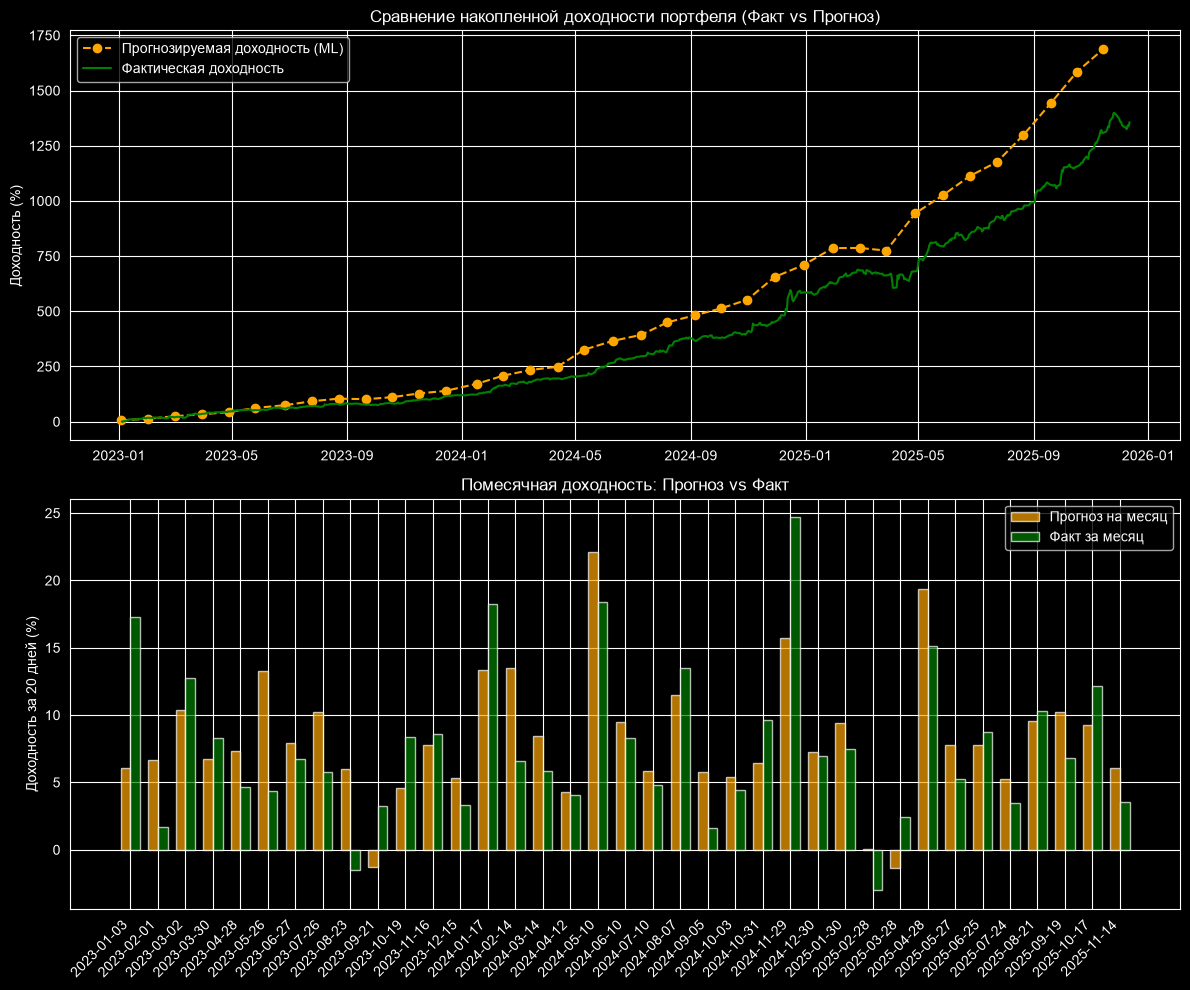

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# График 1: Сравнение накопленной доходности (Факт vs Прогноз)
axes[0].plot(monthly_dates, cum_predicted * 100, label="Прогнозируемая доходность (ML)", color="orange", linestyle="--", marker="o")
axes[0].plot(cum_actual_daily.index, cum_actual_daily * 100, label="Фактическая доходность", color="green")
axes[0].set_title("Сравнение накопленной доходности портфеля (Факт vs Прогноз)")
axes[0].set_ylabel("Доходность (%)")
axes[0].grid(True)
axes[0].legend()

x = np.arange(len(period_dates))
width = 0.35

axes[1].bar(x - width/2, np.array(predicted_monthly_returns) * 100, width, label="Прогноз на месяц", color="orange", alpha=0.7)
axes[1].bar(x + width/2, np.array(actual_monthly_returns) * 100, width, label="Факт за месяц", color="green", alpha=0.7)
axes[1].set_title("Помесячная доходность: Прогноз vs Факт")
axes[1].set_xticks(x)
axes[1].set_xticklabels(period_dates, rotation=45, ha="right")
axes[1].set_ylabel("Доходность за 20 дней (%)")
axes[1].grid(True, axis="y")
axes[1].legend()

plt.tight_layout()
plt.show()

In [25]:
from pypfopt import EfficientFrontier, risk_models
tickers = [
    "MSFT",
    "GOOGL",
    "NVDA",
    "AMZN",
    "AVGO",
    "JPM",
    "JNJ",
    "KO",
    "V",
    "LLY"
]

'''
tickers = [
    "MSFT",
    "GOOGL",
    "NVDA",
    "JNJ",
    "AMZN",
]
'''
'''
tickers = [
    "JPM",
    "PG",    # Procter & Gamble
    "KO",    # Coca-Col   # PepsiCo
    "MCD",   # McDonald's
    "WMT",   # Walmart
    "COST",  # Costco
    "ABBV",  # AbbVie
    "CL"   # Merck
]
'''
data = yf.download(tickers, start="2020-01-01", end="2026-01-01")['Close']

returns_20 = data.pct_change(20).shift(-20)

def create_sequences_and_targets(prices_scaled, targets_df, seq_len=30):
    X, y = [], []
    # На шаге t последние известная доходность за 20 дней известна для точки t - 20
    # Поэтому берём все валидные пары без выброса крайних 20 дней
    valid_targets = targets_df.dropna()
    valid_indices = valid_targets.index

    # Строим последовательности только по строкам, где таргет НЕ NaN
    prices_df = pd.DataFrame(prices_scaled, index=targets_df.index)

    for i in range(seq_len, len(prices_df)):
        current_date = prices_df.index[i]
        if current_date in valid_indices:
            X.append(prices_df.iloc[i - seq_len : i].values)
            y.append(valid_targets.loc[current_date].values)

    return np.array(X), np.array(y)

# 3. Настройки Walk-Forward
train_window = 252 * 3  # 3 года обучения
test_step = 20          # Шаг в 20 дней
seq_len = 30
horizon = 20

weights_records = []
period_dates = []

predicted_monthly_returns = []
actual_monthly_returns = []
actual_daily_series = []

# 4. Основной цикл Walk-Forward
for t in range(train_window, len(data) - test_step, test_step):

    current_date = data.index[t]
    period_dates.append(current_date.strftime('%Y-%m-%d'))

    # А. Строгий срез истории до момента t
    train_prices = data.iloc[t - train_window : t]
    train_targets = returns_20.iloc[t - train_window : t]

    # Б. Нормализация (fit строго на train)
    scaler = StandardScaler()
    train_prices_scaled = scaler.fit_transform(train_prices)

    # В. Создание генераций без Lookahead Bias
    X_train, y_train = create_sequences_and_targets(
        train_prices_scaled, train_targets, seq_len=seq_len
    )

    # Г. Обучение LSTM
    model = Sequential([
        LSTM(64, input_shape=(seq_len, len(tickers)), return_sequences=False),
        Dropout(0.2),
        Dense(len(tickers))
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

    # Д. Прогноз на следующие 20 дней (используем последние seq_len дней до точки t)
    last_seq = train_prices_scaled[-seq_len:][np.newaxis, :, :]
    pred_20d_returns = model.predict(last_seq, verbose=0).flatten()

    # Е. Оптимизация портфеля через PyPortfolioOpt
    cov_matrix = risk_models.risk_matrix(train_prices, method="ledoit_wolf")

    # Приводим 20-дневный прогноз к годовому выражению для сопоставимости с ковариацией
    pred_annual_returns = pred_20d_returns * 12
    pred_series = pd.Series(pred_annual_returns, index=tickers)

    ef = EfficientFrontier(pred_series, cov_matrix, weight_bounds=(0, 0.4))

    try:
        ef.max_sharpe(risk_free_rate=0.0)
    except Exception:
        ef = EfficientFrontier(pred_series, cov_matrix, weight_bounds=(0, 0.4))
        ef.min_volatility()

    cleaned_weights = ef.clean_weights()
    weights = np.array([cleaned_weights[ticker] for ticker in tickers])
    weights_records.append(weights)

    # Ж. Фиксация прогноза и фактических результатов
    pred_portfolio_20d = np.sum(pred_20d_returns * weights)
    predicted_monthly_returns.append(pred_portfolio_20d)

    # Корректный срез с захватом дня (t - 1) для сохранения доходности первого дня
    test_actual_prices = data.iloc[t - 1 : t + test_step]
    actual_daily_returns = test_actual_prices.pct_change().dropna()

    port_daily_ret = (actual_daily_returns * weights).sum(axis=1)
    actual_daily_series.append(port_daily_ret)

    actual_portfolio_20d = (1 + port_daily_ret).prod() - 1
    actual_monthly_returns.append(actual_portfolio_20d)

# 6. Формирование таблицы весов
weights_df = pd.DataFrame(weights_records, index=period_dates, columns=tickers)
print("\n--- ВЕСА ПОРТФЕЛЯ ПО ДАТАМ ПЕРЕБАЛАНСИРОВКИ ---")
print((weights_df * 100).round(2).astype(str) + "%")

# 7. Расчет накопительной прогнозируемой и фактической доходностей
cum_predicted = np.cumprod(1 + np.array(predicted_monthly_returns)) - 1
cum_actual_daily = (1 + pd.concat(actual_daily_series)).cumprod() - 1

# Сопоставление дат для помесячного сравнения
monthly_dates = pd.to_datetime(period_dates)

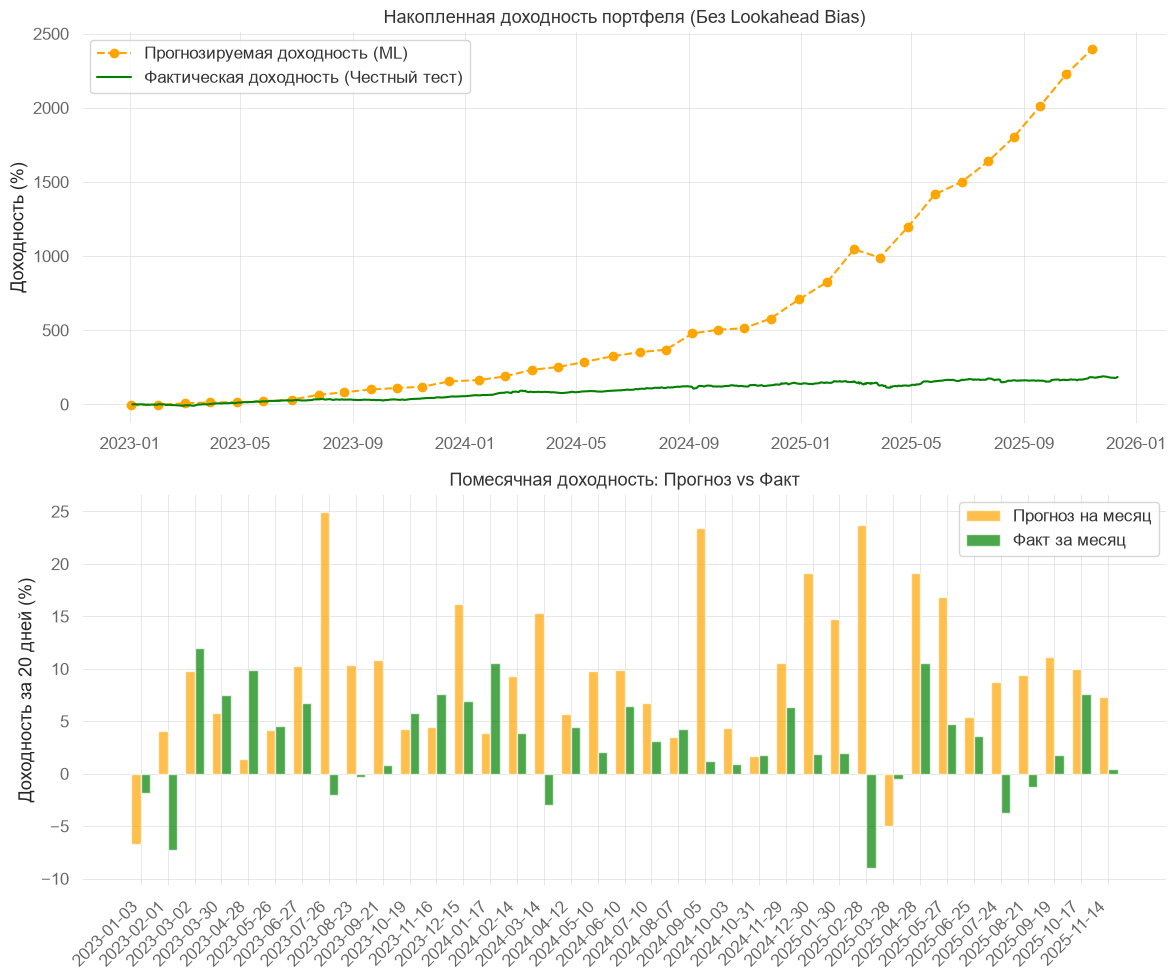

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# График 1: Сравнение накопленной доходности (Факт vs Прогноз)
axes[0].plot(monthly_dates, cum_predicted * 100, label="Прогнозируемая доходность (ML)", color="orange", linestyle="--", marker="o")
axes[0].plot(cum_actual_daily.index, cum_actual_daily * 100, label="Фактическая доходность", color="green")
axes[0].set_title("Сравнение накопленной доходности портфеля (Факт vs Прогноз)")
axes[0].set_ylabel("Доходность (%)")
axes[0].grid(True)
axes[0].legend()

x = np.arange(len(period_dates))
width = 0.35

axes[1].bar(x - width/2, np.array(predicted_monthly_returns) * 100, width, label="Прогноз на месяц", color="orange", alpha=0.7)
axes[1].bar(x + width/2, np.array(actual_monthly_returns) * 100, width, label="Факт за месяц", color="green", alpha=0.7)
axes[1].set_title("Помесячная доходность: Прогноз vs Факт")
axes[1].set_xticks(x)
axes[1].set_xticklabels(period_dates, rotation=45, ha="right")
axes[1].set_ylabel("Доходность за 20 дней (%)")
axes[1].grid(True, axis="y")
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
import quantstats as qs

# 1. Объединяем ежедневные доходности портфеля в один Pandas Series
portfolio_returns = pd.concat(actual_daily_series)
portfolio_returns.name = "LSTM_Portfolio"

# Удаляем временную зону (если есть) для совпадения индексов
portfolio_returns.index = pd.to_datetime(portfolio_returns.index).tz_localize(None)

# 2. Загружаем бенчмарк (S&P 500 - SPY) за тот же период тестирования
spy = yf.download("SPY", start=portfolio_returns.index[0], end=portfolio_returns.index[-1])["Close"]
spy_returns = spy.pct_change().dropna()
spy_returns.name = "SPY"
spy_returns.index = pd.to_datetime(spy_returns.index).tz_localize(None)

# Синхронизируем даты портфеля и бенчмарка
df_returns = pd.concat([portfolio_returns, spy_returns], axis=1).dropna()
port_ret = df_returns["LSTM_Portfolio"]
bench_ret = df_returns["SPY"]

# 3. Расширенная аналитика в консоли
print("\n=== ОСНОВНЫЕ МЕТРИКИ ПОРТФЕЛЯ (QuantStats) ===")
qs.extend_pandas()

print(f"CAGR (Годовая доходность): {qs.stats.cagr(port_ret) * 100:.2f}%")
print(f"Коэффициент Шарпа:         {qs.stats.sharpe(port_ret):.2f}")
print(f"Коэффициент Сортино:       {qs.stats.sortino(port_ret):.2f}")
print(f"Максимальная просадка:     {qs.stats.max_drawdown(port_ret) * 100:.2f}%")
print(f"Винрейт (Доля прибыльных дней): {qs.stats.win_rate(port_ret) * 100:.2f}%")

# 4. Визуальный сводный отчет (Графики)
qs.plots.snapshot(port_ret, title="LSTM + PyPortfolioOpt Performance", show=True)

# 5. Генерация полного HTML-отчета
qs.reports.html(port_ret, benchmark=bench_ret, output="portfolio_report.html", title="LSTM Portfolio vs S&P 500")
print("\n Полный HTML-отчет сохранен в файл 'portfolio_report.html'")


 Полный HTML-отчет сохранен в файл 'portfolio_report.html'
